# 1. Problem Understanding

# 2. Load & Inspect Image

# 3. Preprocessing
    - grayscale
    - threshold
    - inspect mask

# 4. Extract Curve
    - find curve pixels column-by-column
    - top/bottom boundary
    - centerline

# 5. Handle Missing Points
    - identify gaps
    - interpolate small gaps

# 6. Smooth Curve
    - plot raw vs smoothed curve

# 7. Detect Maxima & Minima
    - local extrema
    - handle flat regions
    - filter insignificant extrema

# 8. Visualize Results
    - overlay maxima/minima on image

# 9. Test / Failure Analysis
    - what works?
    - what fails?
    - why?

# 10. Final Algorithm
    - summarize the final approach

In [1]:
# Importing libraries

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d

Image shape:  (235, 680, 3)


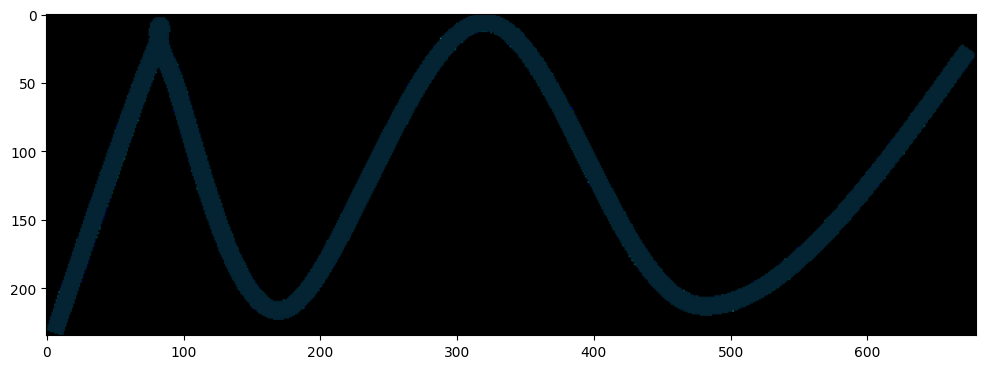

In [2]:
# Load the image
image_path = "/content/image.png"

image = cv.imread(image_path)
if image is None:
  raise FileNotFoundError(f"Could not load image {image_path}")

print("Image shape: ", image.shape)

image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)

plt.figure(figsize = (12, 6))

plt.imshow(image_rgb)
plt.show()


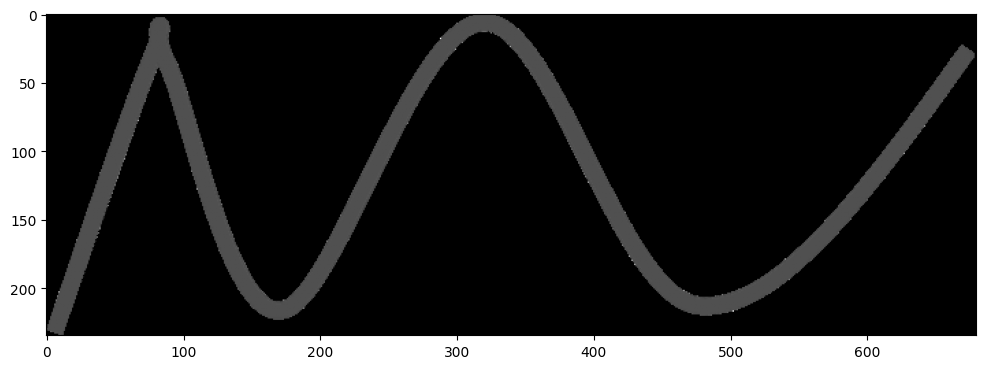

In [3]:
# Converting to grayscale

gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

plt.figure(figsize = (12, 6))
plt.imshow(gray, cmap = "gray")
plt.show()

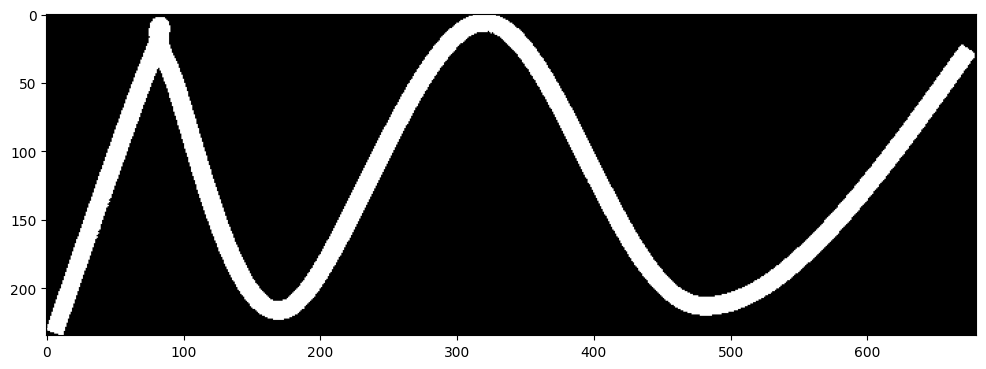

In [4]:
# Threshold the curve

threshold_value = 10

_, binary = cv.threshold(gray, threshold_value, 255, cv.THRESH_BINARY)

plt.figure(figsize = (12, 6))
plt.imshow(binary, cmap = "gray")
plt.show()

In [5]:
# Extract curve pixels

height, width = binary.shape

curve_points = []

for x in range(width):
  ys = np.where(binary[:, x] > 0)[0]

  if len(ys) == 0:
    continue

  top_y = ys.min()
  bottom_y = ys.max()

  center_y = (top_y + bottom_y) / 2.0

  curve_points.append((x, center_y))



In [6]:
# convert list to numpy array

curve_points = np.array(curve_points)
print("Total curve points: ", len(curve_points))
print("First 10 curve points: ", curve_points[:10])

Total curve points:  679
First 10 curve points:  [[  0.  230. ]
 [  1.  229. ]
 [  2.  227.5]
 [  3.  226.5]
 [  4.  225. ]
 [  5.  223.5]
 [  6.  222.5]
 [  7.  221. ]
 [  8.  219.5]
 [  9.  218.5]]


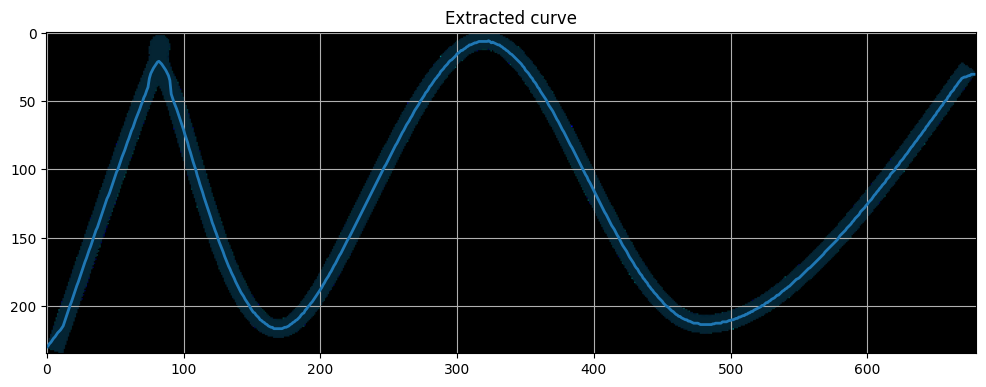

In [7]:
# Visualize extracted centerline

x_values = curve_points[:, 0]
y_values = curve_points[:, 1]

plt.figure(figsize = (12, 6))
plt.imshow(image_rgb)

plt.plot(x_values, y_values, linewidth = 2)
plt.title("Extracted curve")
plt.grid()
plt.show()

In [8]:
# Handling missing x-values

x_diff = np.diff(x_values)
print("Largest gap in x: ", x_diff.max())

Largest gap in x:  1.0


In [15]:
# Considering the region, where the curve actually exists

x_start = int(x_values.min())
x_end = int(x_values.max())

full_x = np.arange(x_start, x_end + 1)
full_y = np.full(len(full_x), np.nan)

for x, y in curve_points:
  full_y[int(x - x_start)] = y

In [16]:
print(len(x_values), len(full_x), len(y_values), len(full_y))

679 679 679 679


In [17]:
# Inspect missing values

missing_count = np.isnan(full_y).sum()
print("Missing point: ", missing_count)

Missing point:  0


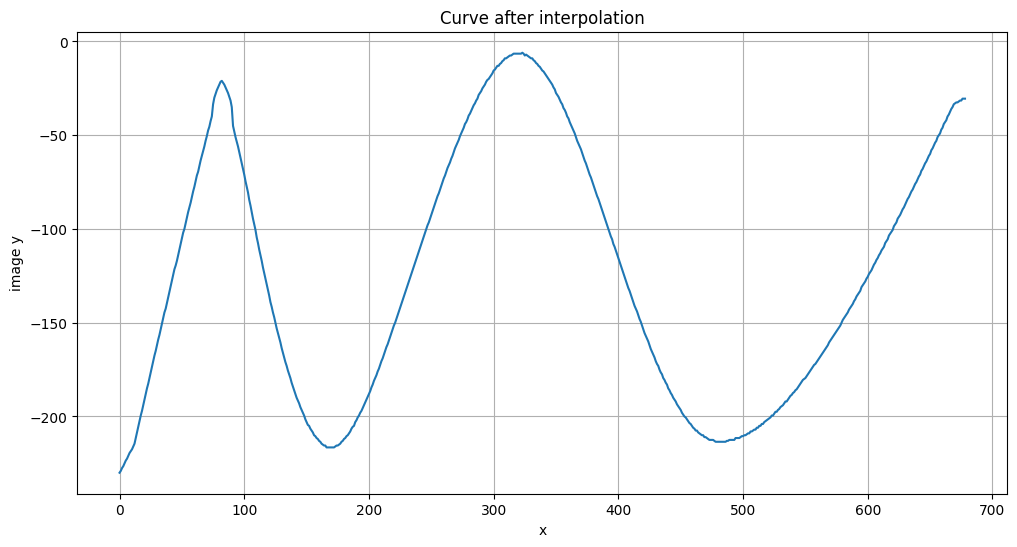

In [19]:
# Interpolate small missing gaps

valid = ~np.isnan(full_y)

interpolated_y = full_y.copy()

interpolated_y[~valid] = np.interp(full_x[~valid], full_x[valid], full_y[valid])

plt.figure(figsize = (12, 6))
plt.plot(full_x, -interpolated_y)

plt.xlabel("x")
plt.ylabel("image y")
plt.title("Curve after interpolation")

plt.grid()
plt.show()

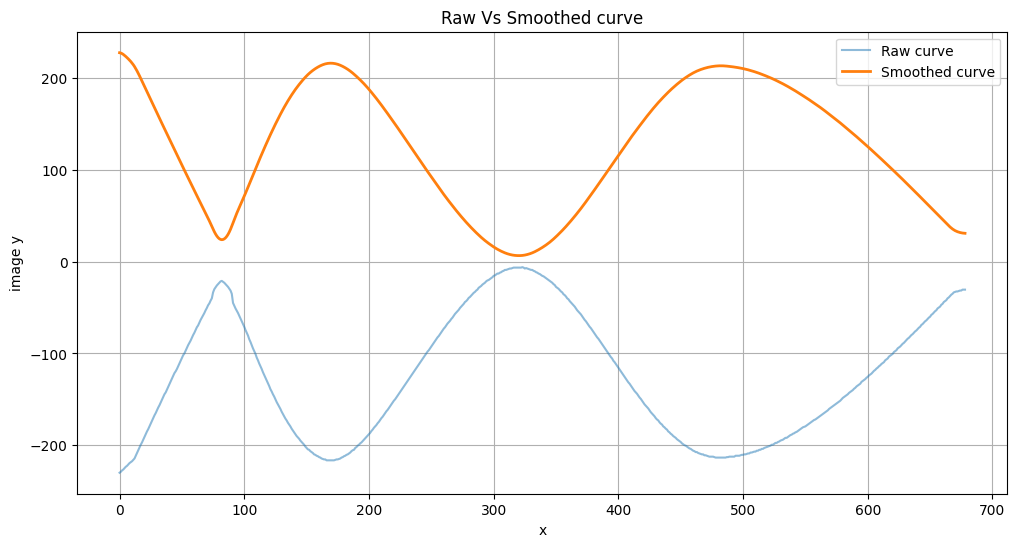

In [22]:
# Smooth the curve

sigma = 3
smoothed_y = gaussian_filter1d(interpolated_y, sigma = sigma)

# compare raw and smoothed curve
plt.figure(figsize = (12, 6))

plt.plot(full_x, -interpolated_y, alpha = 0.5, label = "Raw curve")

plt.plot(full_x, smoothed_y, linewidth = 2, label = "Smoothed curve")

plt.xlabel("x")
plt.ylabel("image y")
plt.title("Raw Vs Smoothed curve")

plt.legend()
plt.grid()
plt.show()

In [26]:
# Detecting Maxima and Minima

maxima_indices, maximum_properties = find_peaks(-smoothed_y, distance = 30, prominence = 5)

minima_indices, minimum_properties = find_peaks(smoothed_y, distance = 30, prominence = 5)

print(maxima_indices)
print(minima_indices)

[ 82 320]
[169 482]


In [28]:
# Inspect detected Extrema

maxima = np.column_stack((full_x[maxima_indices], smoothed_y[maxima_indices]))

minima = np.column_stack((full_x[minima_indices], smoothed_y[minima_indices]))

print("Maxima: ", maxima)
print("\nMinima: ", minima)

Maxima:  [[ 82.          23.92049171]
 [320.           6.57487729]]

Minima:  [[169.         216.24136489]
 [482.         213.40984351]]


In [30]:
# Visualizing with origianl / unsmoothed y_values

maxima = np.column_stack((full_x[maxima_indices], full_y[maxima_indices]))

minima = np.column_stack((full_x[minima_indices], full_y[minima_indices]))

print("Maxima: ", maxima)
print("\nMinima: ", minima)

Maxima:  [[ 82.   21. ]
 [320.    6.5]]

Minima:  [[169.  216.5]
 [482.  213.5]]


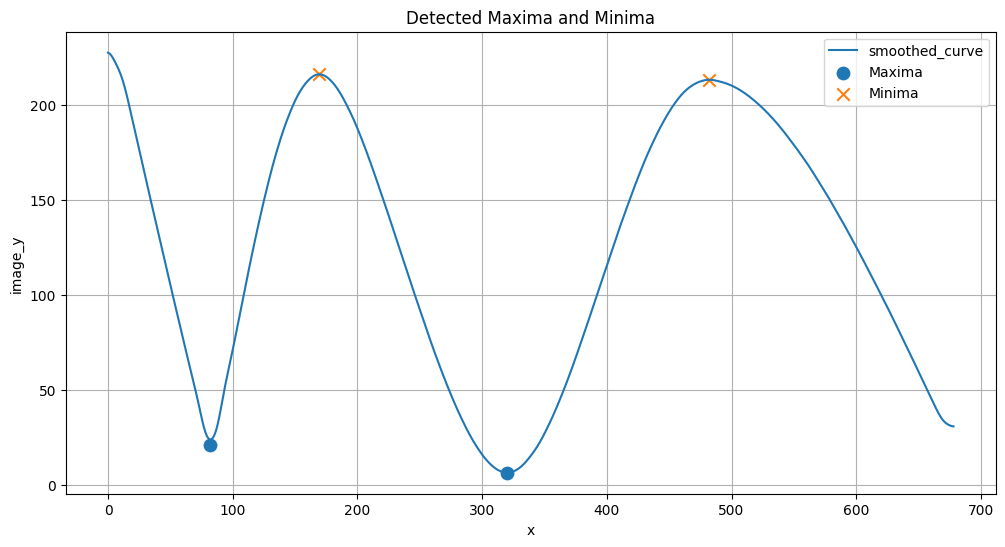

In [34]:
# Plot Extrema on the 1D curve

plt.figure(figsize = (12, 6))

plt.plot(full_x, smoothed_y, label = "smoothed_curve")

plt.scatter(maxima[:, 0], maxima[:, 1], s= 80, marker = "o", label = "Maxima")

plt.scatter(minima[:, 0], minima[:, 1], s= 80, marker = "x", label = "Minima")

plt.xlabel("x")
plt.ylabel("image_y")
plt.title("Detected Maxima and Minima")

plt.legend()
plt.grid()
plt.show()

In [38]:
maxima, minima

(array([[ 82. ,  21. ],
        [320. ,   6.5]]),
 array([[169. , 216.5],
        [482. , 213.5]]))

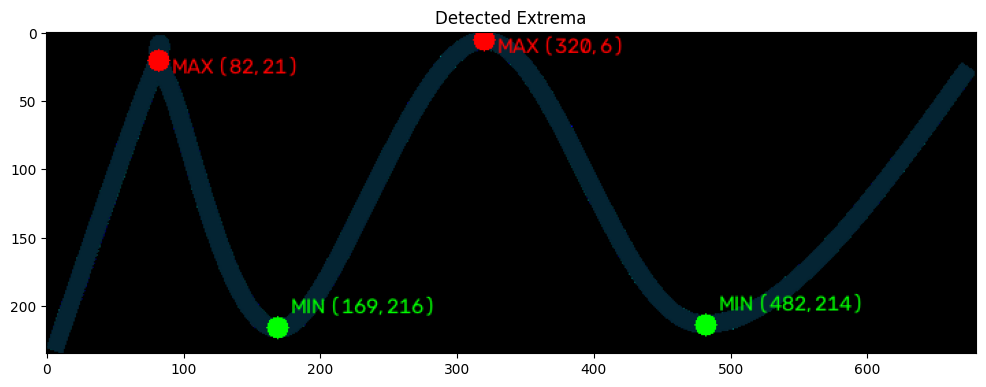

In [44]:
# Overlay results on the original image

result = image_rgb.copy()

for x, y in maxima:
  x, y = int(round(x)), int(round(y))

  cv.circle(result, (x, y), 8, (255, 0, 0), -1)                   # red

  cv.putText(result, f"MAX ({x}, {y})", (x+10, y+10), cv.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv.LINE_AA)



for x, y in minima:
  x, y = int(round(x)), int(round(y))

  cv.circle(result, (x, y), 8, (0, 255, 0), -1)                   # green

  cv.putText(result, f"MIN ({x}, {y})", (x+10, y-10), cv.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1, cv.LINE_AA)


plt.figure(figsize = (12, 6))
plt.imshow(result)

plt.title("Detected Extrema")
plt.show()
